<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary

In [70]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 1e-4
epochs = 30
input_lengths = [20,30, 50]
hidden_size = 100
dropout_rate = 0.3

device

device(type='cuda', index=0)

In [91]:

#Imported directly from Dr. Tabkhi's Github
# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
def createTrainAndTestLoaders(sequence_length):



  # Encode the text into integers
  encoded_text = [char_to_int[ch] for ch in text]

  # Create sequences and targets
  sequences = []
  targets = []
  for i in range(0, len(encoded_text) - sequence_length):
      seq = encoded_text[i:i+sequence_length]
      target = encoded_text[i+sequence_length]
      sequences.append(seq)
      targets.append(target)

  # Convert lists to PyTorch tensors
  sequences = torch.tensor(sequences, dtype=torch.long)
  targets = torch.tensor(targets, dtype=torch.long)

  # Step 3: Create a dataset class
  class CharDataset(Dataset):
      def __init__(self, sequences, targets):
          self.sequences = sequences
          self.targets = targets

      def __len__(self):
          return len(self.sequences)

      def __getitem__(self, index):
          return self.sequences[index], self.targets[index]

  # Instantiate the dataset
  dataset = CharDataset(sequences, targets)

  # Step 4: Create data loaders
  batch_size = 1024
  train_size = int(len(dataset) * 0.8)
  test_size = len(dataset) - train_size
  train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

  train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, pin_memory=True)
  test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size, pin_memory=True)

  if(train_loader and test_loader):
    print(f"Train and Test Loader Created - Sequence Length: {sequence_length}")
    return train_loader, test_loader
  else:
    print("Not created")

  # Now `train_loader` and `test_loader` are ready to be used in a training loop

In [72]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text)}")
sorted_text = list(sorted(set(text)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 1115394
Total Unique Characters: 65
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


In [73]:
#Create Model
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)


  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.rnn(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=2, dropout=dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    return output

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True, num_layers=2, dropout = dropout_rate)
    self.dropout = nn.Dropout(p = dropout_rate)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.dropout(output[:, -1, :])
    output = self.fc1(output)
    return output

In [74]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [75]:
def createMODELandLOSS(model):
  model = model.upper()
  valid_models = {'RNN', 'LSTM', 'GRU'}
  if model not in valid_models:
    raise ValueError(f"Invalid Type {model}. Expected one of {valid_models}")
  if(model == "RNN"):
    model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "LSTM"):
    model = LSTM(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "GRU"):
    model = GRU(len(sorted_text), hidden_size, len(sorted_text)).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)
  return model, criterion, optimizer

In [76]:
def run(modelName):
##Data Preprocessing and converting to tensor
  for i, input_length in enumerate(input_lengths):

    train_loader, test_loader = createTrainAndTestLoaders(input_length)
    model, criterion, optimizer = createMODELandLOSS(modelName)

    ###This is where training begins
    #Lists for storing loss and validation values
    train_loss_list = []
    val_loss_list = []
    val_accuracy_list = []


    #Create a new training loop for each input_length
    for epoch in range(epochs):
      model.train()

      for data in train_loader:
        X_train, y_train = data
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        optimizer.zero_grad()
        y_pred = model(X_train)  # Forward pass
        loss = criterion(y_pred, y_train)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update model parameters

      train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                          #to the training loss list (of all epochs)


      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        for data in test_loader:
          X_val, y_val = data
          X_val = X_val.to(device)
          y_val = y_val.to(device)
          val_output = model(X_val) # Take test dataset and run it through this epoch's model

          val_loss = criterion(val_output, y_val) #Find the loss

          _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

          val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                            #compare it to the ground truth, and find how accurate we are

        val_loss_list.append(val_loss.item())
        val_accuracy_list.append(val_accuracy.item())


        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

    createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
    print(summary(model, input_size = (1,sequence_length), dtypes=[torch.long]))


Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.7782, Val Accuracy: 0.3160, Val Loss: 2.6219
Epoch 1, Loss: 2.5325, Val Accuracy: 0.3576, Val Loss: 2.3186
Epoch 2, Loss: 2.2745, Val Accuracy: 0.3875, Val Loss: 2.1808
Epoch 3, Loss: 2.1973, Val Accuracy: 0.4118, Val Loss: 2.0870
Epoch 4, Loss: 2.1151, Val Accuracy: 0.4245, Val Loss: 2.0213
Epoch 5, Loss: 2.2609, Val Accuracy: 0.4383, Val Loss: 1.9664
Epoch 6, Loss: 2.2673, Val Accuracy: 0.4429, Val Loss: 1.9247
Epoch 7, Loss: 1.9911, Val Accuracy: 0.4498, Val Loss: 1.8881
Epoch 8, Loss: 2.1437, Val Accuracy: 0.4510, Val Loss: 1.8597
Epoch 9, Loss: 1.9908, Val Accuracy: 0.4533, Val Loss: 1.8360
Epoch 10, Loss: 1.9120, Val Accuracy: 0.4648, Val Loss: 1.8139
Epoch 11, Loss: 2.1365, Val Accuracy: 0.4740, Val Loss: 1.7931
Epoch 12, Loss: 1.9740, Val Accuracy: 0.4740, Val Loss: 1.7742
Epoch 13, Loss: 2.1222, Val Accuracy: 0.4833, Val Loss: 1.7600
Epoch 14, Loss: 1.9065, Val Accuracy: 0.4821, Val Loss: 1.7433
Epoch 15, Los

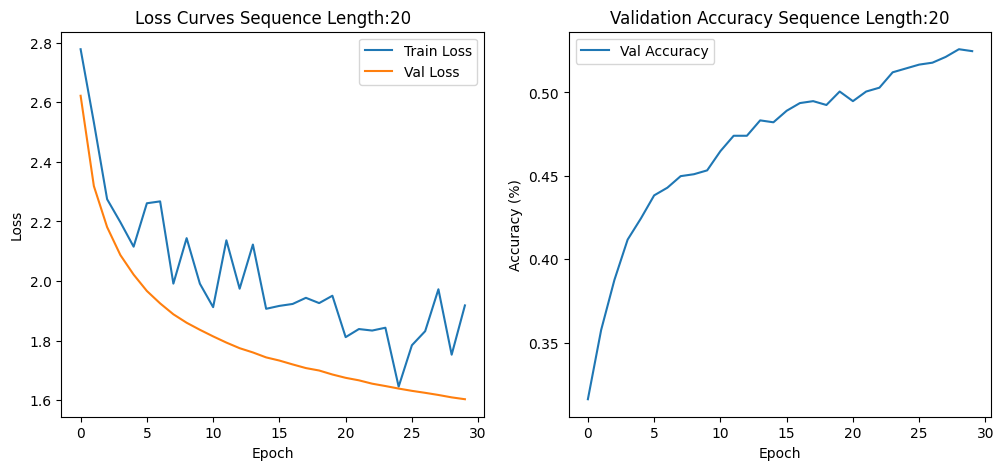

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 100]              6,500
├─LSTM: 1-2                              [1, 20, 100]              161,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 174,665
Trainable params: 174,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.25
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.70
Estimated Total Size (MB): 0.73
Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.6513, Val Accuracy: 0.2844, Val Loss: 2.6560
Epoch 1, Loss: 2.4316, Val Accuracy: 0.3468, Val Loss: 2.3793
Epoch 2, Loss: 2.3559, Val Accuracy: 0.3584, Val Loss: 2.2470
Epoch 3, Loss: 2.2295, Val Accuracy: 0.3815, Val Loss: 2.1556
Epoch 4, Loss: 2.2757, Val Accuracy: 

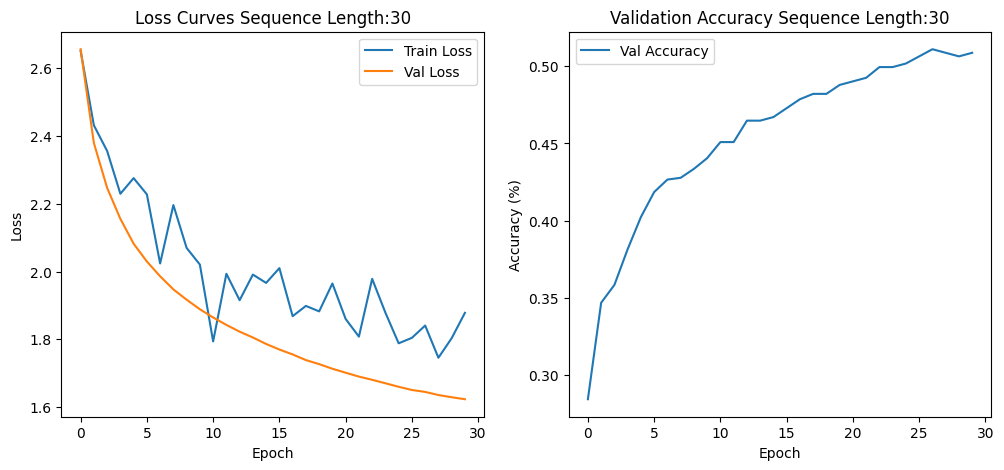

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 100]              6,500
├─LSTM: 1-2                              [1, 30, 100]              161,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 174,665
Trainable params: 174,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.86
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.70
Estimated Total Size (MB): 0.75
Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.7499, Val Accuracy: 0.2904, Val Loss: 2.6326
Epoch 1, Loss: 2.4686, Val Accuracy: 0.3531, Val Loss: 2.3329
Epoch 2, Loss: 2.4035, Val Accuracy: 0.3775, Val Loss: 2.2059
Epoch 3, Loss: 2.3055, Val Accuracy: 0.3972, Val Loss: 2.1237
Epoch 4, Loss: 2.0982, Val Accuracy: 

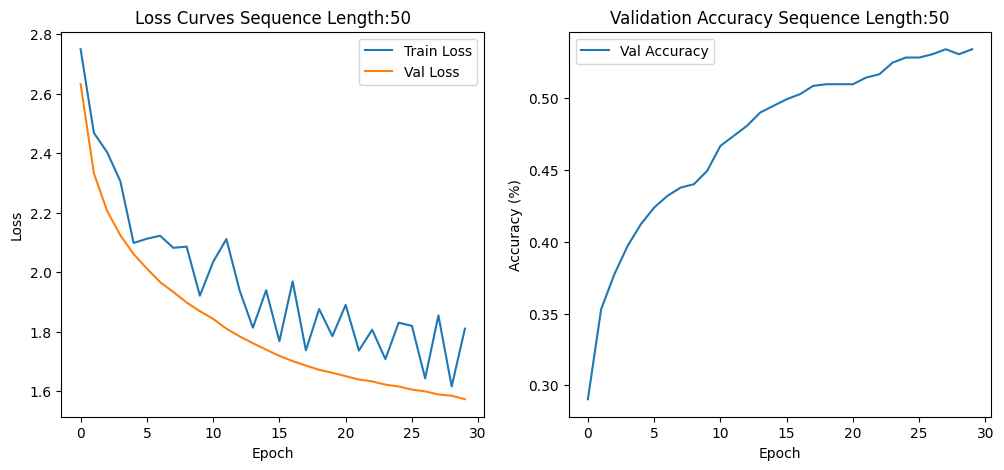

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 100]              6,500
├─LSTM: 1-2                              [1, 50, 100]              161,600
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 174,665
Trainable params: 174,665
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 8.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.70
Estimated Total Size (MB): 0.78


In [77]:
run("LSTM")

Train and Test Loader Created - Sequence Length: 20
Epoch 0, Loss: 2.5941, Val Accuracy: 0.3080, Val Loss: 2.4647
Epoch 1, Loss: 2.3615, Val Accuracy: 0.3633, Val Loss: 2.2302
Epoch 2, Loss: 2.2034, Val Accuracy: 0.4002, Val Loss: 2.1141
Epoch 3, Loss: 2.2141, Val Accuracy: 0.4129, Val Loss: 2.0330
Epoch 4, Loss: 2.1419, Val Accuracy: 0.4198, Val Loss: 1.9729
Epoch 5, Loss: 2.0075, Val Accuracy: 0.4337, Val Loss: 1.9260
Epoch 6, Loss: 1.9365, Val Accuracy: 0.4464, Val Loss: 1.8898
Epoch 7, Loss: 1.9542, Val Accuracy: 0.4498, Val Loss: 1.8666
Epoch 8, Loss: 1.9837, Val Accuracy: 0.4614, Val Loss: 1.8374
Epoch 9, Loss: 1.9804, Val Accuracy: 0.4660, Val Loss: 1.8180
Epoch 10, Loss: 2.0257, Val Accuracy: 0.4706, Val Loss: 1.8017
Epoch 11, Loss: 1.8172, Val Accuracy: 0.4775, Val Loss: 1.7872
Epoch 12, Loss: 1.9064, Val Accuracy: 0.4810, Val Loss: 1.7735
Epoch 13, Loss: 1.8750, Val Accuracy: 0.4833, Val Loss: 1.7637
Epoch 14, Loss: 1.9006, Val Accuracy: 0.4971, Val Loss: 1.7489
Epoch 15, Los

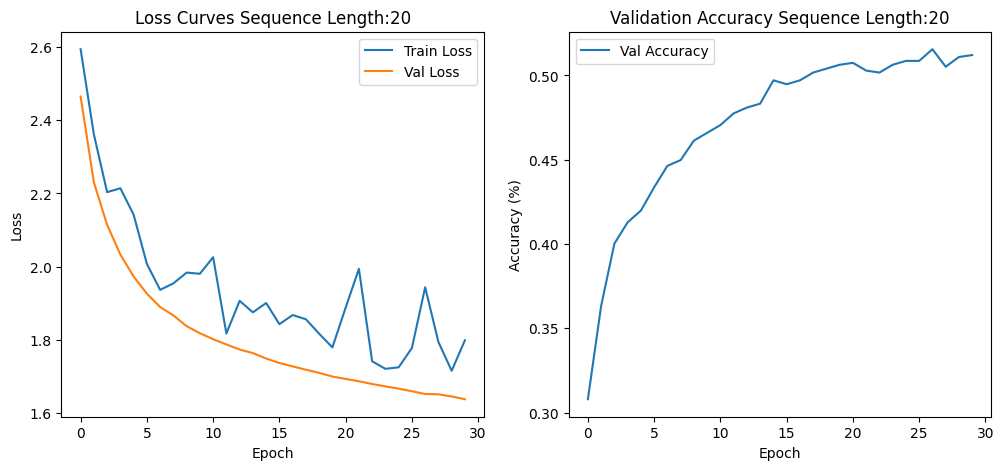

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 65]                   --
├─Embedding: 1-1                         [1, 20, 100]              6,500
├─GRU: 1-2                               [1, 20, 100]              121,200
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 134,265
Trainable params: 134,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.44
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.54
Estimated Total Size (MB): 0.57
Train and Test Loader Created - Sequence Length: 30
Epoch 0, Loss: 2.5212, Val Accuracy: 0.3052, Val Loss: 2.4647
Epoch 1, Loss: 2.2654, Val Accuracy: 0.3549, Val Loss: 2.2291
Epoch 2, Loss: 2.2631, Val Accuracy: 0.3815, Val Loss: 2.1160
Epoch 3, Loss: 2.2203, Val Accuracy: 0.3827, Val Loss: 2.0458
Epoch 4, Loss: 2.1318, Val Accuracy: 

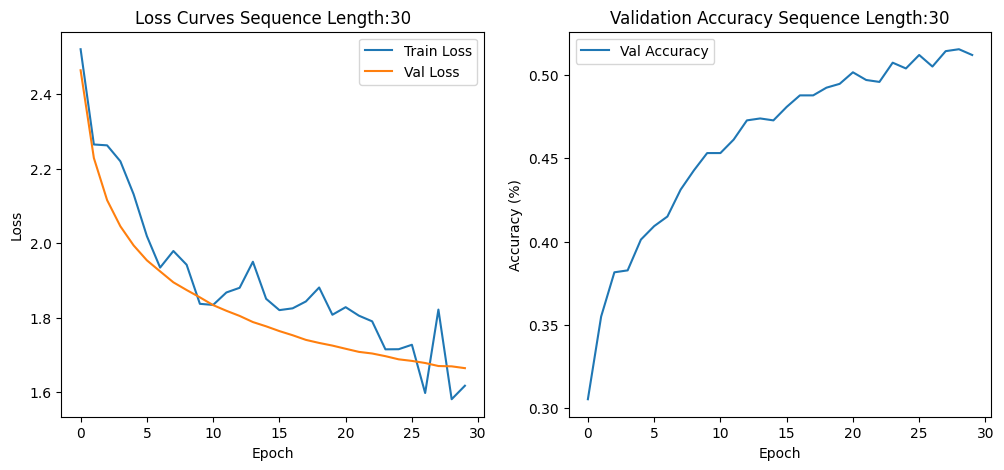

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 65]                   --
├─Embedding: 1-1                         [1, 30, 100]              6,500
├─GRU: 1-2                               [1, 30, 100]              121,200
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 134,265
Trainable params: 134,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.65
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.54
Estimated Total Size (MB): 0.59
Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.5164, Val Accuracy: 0.3124, Val Loss: 2.5421
Epoch 1, Loss: 2.4236, Val Accuracy: 0.3589, Val Loss: 2.3107
Epoch 2, Loss: 2.2607, Val Accuracy: 0.3647, Val Loss: 2.2026
Epoch 3, Loss: 2.1157, Val Accuracy: 0.3728, Val Loss: 2.1291
Epoch 4, Loss: 2.1930, Val Accuracy: 

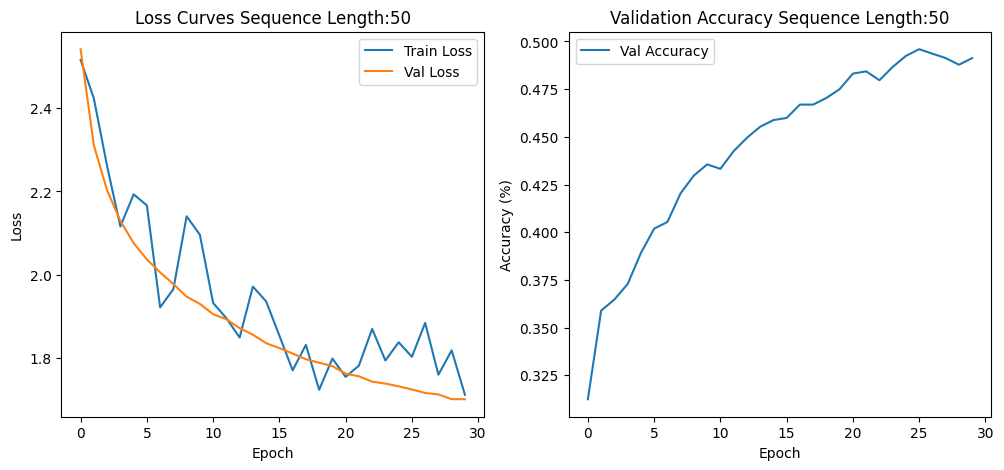

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 65]                   --
├─Embedding: 1-1                         [1, 50, 100]              6,500
├─GRU: 1-2                               [1, 50, 100]              121,200
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 65]                   6,565
Total params: 134,265
Trainable params: 134,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.54
Estimated Total Size (MB): 0.62


In [78]:
run("GRU")

After reviewing the final accuracy of each model. It appears that the LSTM version with sequence length 50 is the best performing. The model doesnt save the weights so we'll retrain with higher epochs to see how high the accuracy can go.

Train and Test Loader Created - Sequence Length: 50
Epoch 0, Loss: 2.7011, Val Accuracy: 0.3020, Val Loss: 2.6953
New highest accuracy model obtained: Epoch: 0, Accuracy: 0.30197444558143616
Epoch 1, Loss: 2.4275, Val Accuracy: 0.3426, Val Loss: 2.4086
New highest accuracy model obtained: Epoch: 1, Accuracy: 0.34262484312057495
Epoch 2, Loss: 2.2868, Val Accuracy: 0.3693, Val Loss: 2.2793
New highest accuracy model obtained: Epoch: 2, Accuracy: 0.3693379759788513
Epoch 3, Loss: 2.2996, Val Accuracy: 0.3937, Val Loss: 2.2010
New highest accuracy model obtained: Epoch: 3, Accuracy: 0.39372822642326355
Epoch 4, Loss: 2.1123, Val Accuracy: 0.4019, Val Loss: 2.1366
New highest accuracy model obtained: Epoch: 4, Accuracy: 0.40185829997062683
Epoch 5, Loss: 2.2009, Val Accuracy: 0.4100, Val Loss: 2.0766
New highest accuracy model obtained: Epoch: 5, Accuracy: 0.4099883735179901
Epoch 6, Loss: 2.0588, Val Accuracy: 0.4228, Val Loss: 2.0223
New highest accuracy model obtained: Epoch: 6, Accurac

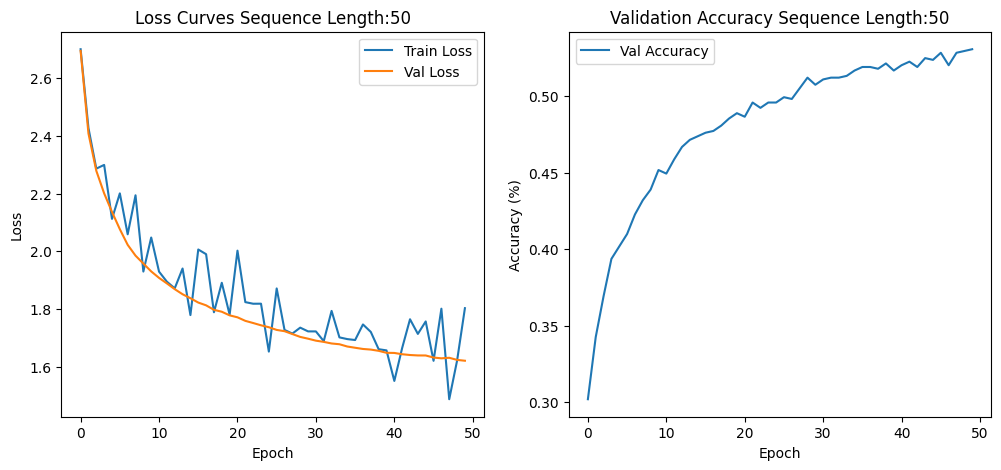

In [87]:
epochs = 50
input_length = 50
train_loader, test_loader = createTrainAndTestLoaders(input_length)
model, criterion, optimizer = createMODELandLOSS("LSTM")

###This is where training begins
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
highest_accuracy = 0.0

#Create a new training loop for each input_length
for epoch in range(epochs):
  model.train()

  for data in train_loader:
    X_train, y_train = data
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    optimizer.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update model parameters

  train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                      #to the training loss list (of all epochs)


  #Here is where we evaluate the model on the current epoch
  model.eval()
  with torch.no_grad():
    for data in test_loader:
      X_val, y_val = data
      X_val = X_val.to(device)
      y_val = y_val.to(device)
      val_output = model(X_val) # Take test dataset and run it through this epoch's model

      val_loss = criterion(val_output, y_val) #Find the loss

      _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

      val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                        #compare it to the ground truth, and find how accurate we are

    val_loss_list.append(val_loss.item())
    val_accuracy_list.append(val_accuracy.item())


    print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

    if val_accuracy.item() > highest_accuracy:
      highest_accuracy = val_accuracy.item()

      best_scoring_model = model.state_dict()
      print(f"New highest accuracy model obtained: Epoch: {epoch}, Accuracy: {val_accuracy.item()}")

createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)

In [88]:
def predict_next_char(model, char_to_ix, ix_to_char, initial_str):
    model.eval()
    temperature = 0.8
    with torch.no_grad():
        initial_input = torch.tensor([char_to_ix[c] for c in initial_str[-sequence_length:]], dtype=torch.long).unsqueeze(0).to(device)
        prediction = model(initial_input)
        probabilities = prediction[0] / temperature
        predicted_index = torch.softmax(probabilities, dim=-1)
        predicted_index = torch.multinomial(predicted_index, num_samples=1).item()
        return ix_to_char[predicted_index]

In [94]:
text = "This is an example text"
for i in range(1000):
  text += predict_next_char(model, char_to_int, int_to_char, text)
print(text)

This is an example text
oTherrant, Hath cinds been me be mine ceent
On the news, the preir days he foul it Richard:
That our lew Titent to flight in I wrears the sinty.

CAPULET:
I, when is honest of my at of are came,
I hour that Morountres of your race, clanes
Which make his pray his libreating with after?

CORIOLANUS:
Hath would not I go take me my resons to spove
I stand heaven of him in everment?
But my lords, will for she her.
 Rome my ustenone me to this? Rome;
That so saint night to the heads be ented,
And or your fair, and brone cholese, dead;
Or his stact his deat and stould have as
apining speech, endice that all that the can
The bear. Betirely coman though a cusse the
the thought breed that condems, of it in struke
With thou true of my offer heard but sort.

BUCKINGHAM:
Where not love me not a fight of in a sape,
Of shall you fast your puster.

POLIXENES:
What he will how be your upon live you so criates.

PAMILLA:
The! earth, and in my sand?

EDBARDA:
To fir it your hould 